In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy import signal, fft, constants, optimize
from io import StringIO
from matplotlib.backends.backend_pdf import PdfPages  
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('test.ipynb'), '..')))
from functions import *


#=====================================
# file paths 
#=====================================

flong = fp_long(primary, energy, sin2theta, runnum)
flist = fp_list(primary, energy, sin2theta, runnum)
finp = fp_inp(primary, energy, sin2theta, runnum)
fNmu = fp_Nmu(primary, energy, sin2theta, runnum)
fNe = fp_Ne(primary, energy, sin2theta, runnum)
fRadE = fp_RadE(primary, energy, sin2theta)

#=====================================
# load data
#=====================================

# antenna positions
xypos = lambda runnum: pd.read_csv(flist, sep=r"\s+",header=None)
ant_x = lambda xpos: xpos.astype(float)/1e2 # x position in m
ant_y =  lambda ypos: ypos.astype(float)/1e2 # y position in m

antx = ant_x(xypos(runnum)[2])
anty = ant_y(xypos(runnum)[3])
antlabels = xypos(runnum)[5]

# muon numbers
datamu = np.load(f'../{fNmu}')
mux = datamu['x']/1e3
muy = datamu['y']/1e3
w_mu = datamu['w']

# electron numbers
datae = np.load(f'../{fNe}')
ex = datae['x']/1e3
ey = datae['y']/1e3
w_e = datae['w']


### shower coordinate ###
with open(finp) as f:
    for line in f:
        parts = line.split()
        if parts[0] == "THETAP":
            thetap = float(parts[1])
        if parts[0] == "PHIP":
            phip = float(parts[1])
        elif parts[0] == "MAGNET":
            Bx, Bz = float(parts[1]), -float(parts[2]) # input Bz possitive downward
            By = 0
            
# shower direction
theta = np.deg2rad(thetap)
phi   = np.deg2rad(phip)

plt.rcParams["font.size"] = 14
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
})

with open(finp, 'r') as file:
    content = file.read()
    print(content)

RUNNR       0
EVTNR       1
SEED        37826731    0    0
SEED        38826731    0    0
SEED        39826732    0    0
NSHOW       1
ERANGE      10.056665328903634e+6    10.056665328903634e+6
ESLOPE      -1.0
PRMPAR      14
THETAP      16.8747    16.8747
PHIP        139.7279    139.7279
THIN        1e-06    10.056665328903634    0.0
THINH       2.00E+02 10.000000
ECUTS       0.02     0.01    4.0E-04 4.00E-04
CASCADE     F F F
ELMFLG      T    T
OBSLEV      284000.0
ECTMAP      1.e11
SIBYLL      T    0
SIBSIG      T
FIXHEI      0.    0
HADFLG      0    1    0    1    0    2
STEPFC      1.0
MUMULT      T
MUADDI      T
MAXPRT      1
MAGNET      16.75  -51.96
LONGI       T     10.  T    T
RADNKG      2.E5
ATMOD       33
DIRECT      /home/2134/scratch/coreas/temp/continuous/star-pattern/proton/lgE_16.0/sin2_0.0/000000/
USER        acoleman
EXIT



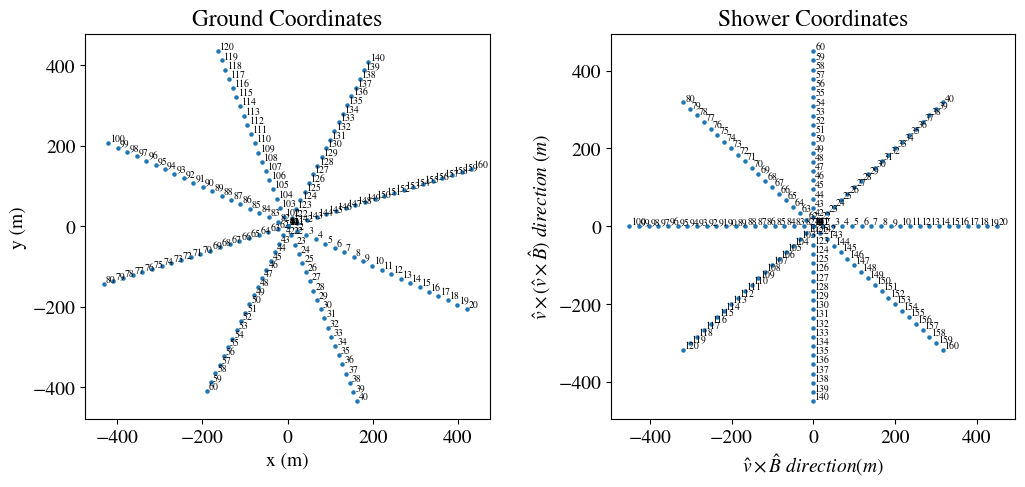

In [10]:
rmant = [label.replace("ant_", "") for label in antlabels]
vxB, vxvxB = (np.empty(160) for _ in range(2))
offset = 5
s = 5

### ground coordinate ###
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.subplots_adjust(wspace=0.3)
plot = axes[0].scatter(antx, anty, s = s)
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
axes[0].set_title("Ground Coordinates")

### shower coordinate ###
for i in range(len(antx)):
    g2s = GroundtoShowerCoordinates(antx[i], anty[i], [theta, phi], [Bx, By, Bz])
    new_x = g2s.vxB()
    new_y = g2s.vxvxB()
    vxB[i] = new_x
    vxvxB[i] = new_y
plot = axes[1].scatter(vxB, vxvxB, s = s)
axes[1].set_xlabel(rf"$\hat{{v}}\times\hat{{B}} \ direction (m)$")
axes[1].set_ylabel(rf"$\hat{{v}} \times (\hat{{v}}\times\hat{{B}}) \ direction \ (m)$")
axes[1].set_title("Shower Coordinates")

for i in range(len(antx)):
    axes[1].text(vxB[i] + offset, vxvxB[i] + offset, f'{rmant[i]}', fontsize=7)
    axes[0].text(antx[i] + offset, anty[i] + offset, f'{rmant[i]}', fontsize=7)

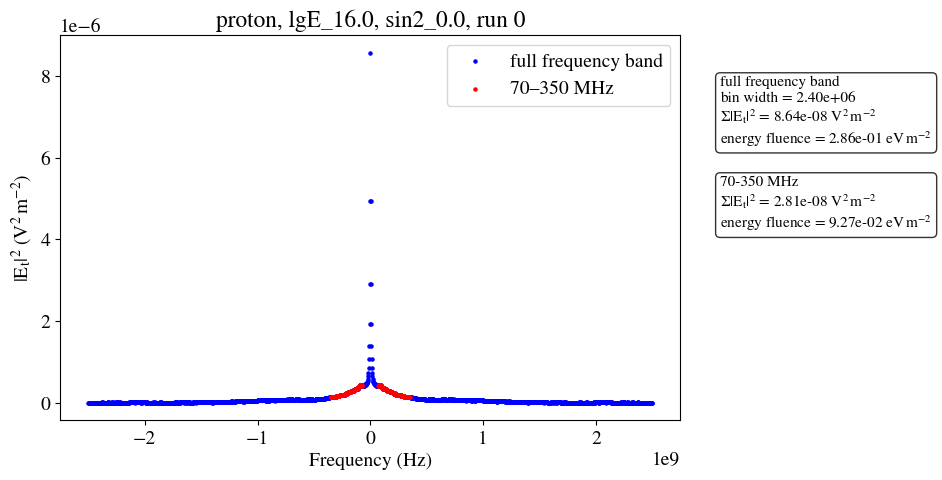

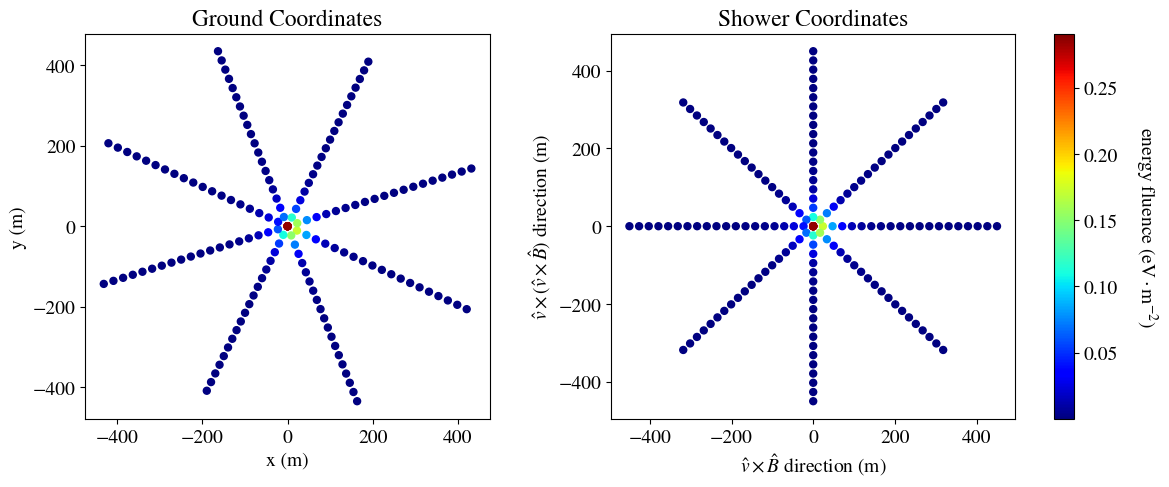

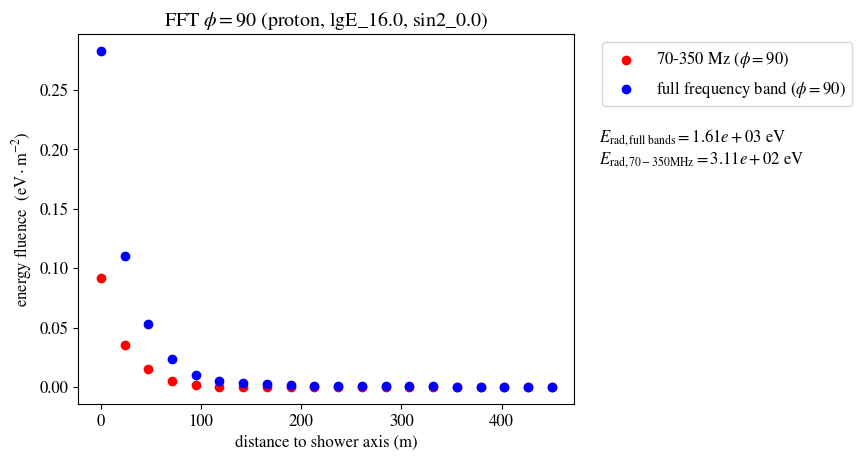

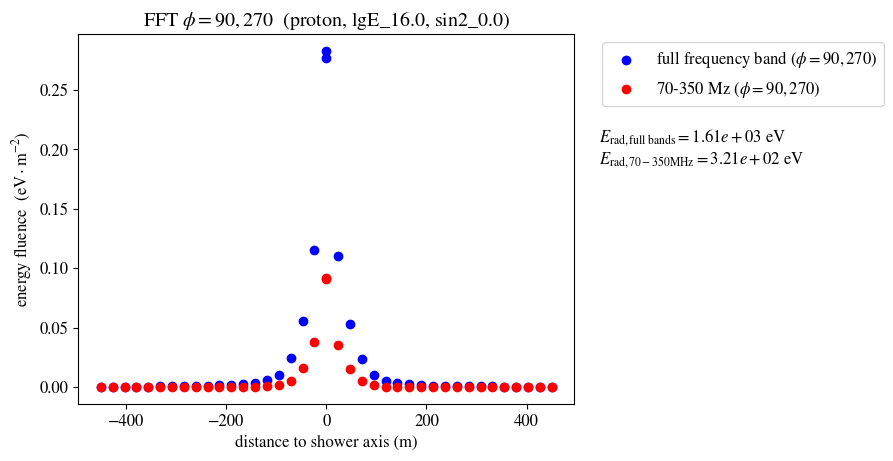

(40, 40)

In [12]:
Nant = 160 #number of total antennas
# create empty arrays of energy fluence, filtered energy fluence, vxB, and vxvxB
ef, eff, vxB, vxvxB = (np.empty(Nant) for _ in range(4))

fmin,fmax = 70e6, 350e6 # frequency range 70-350 MHz

# 160 antenna (Nant = 160) loop
for i, ant_no in enumerate(range (1,Nant+1)):
    
    radio_dat = np.loadtxt(fp_radio(primary, energy, sin2theta, runnum, ant_no))

    # extract data
    time = radio_dat[:,0]
    E_SI = 29979 # electric field converter from cgs unit to SI unit 1 statV/cm≈29,979 V/m
    Ex, Ey, Ez = radio_dat[:,1]*E_SI, radio_dat[:,2]*E_SI, radio_dat[:,3]*E_SI # north, west, vertical electric field in V/m
    Er = np.sqrt(Ex**2 + Ey**2 + Ez**2) 

    # FFT
    dt = time[1] - time[0]
    N  = len(time)
    Efft = fft.fft(Er) # real valued signal, use rfft
    freq = (np.fft.fftfreq(N, dt))

    Efft2 = abs(Efft)**2
    E_sum = fftsum(N, Efft2)

    # restrict energy range
    mask = (abs(freq) >= fmin) & (abs(freq) <= fmax)
    Efft2_mask = abs(Efft[mask])**2
    freq_f = freq[mask]
    E_sum_f = fftsum(N, Efft2_mask)

    # energy fluence 
    ef[i], eff[i] = energyfluence(E_sum), energyfluence(E_sum_f)

    # plot |E|^2 histogram for antenna number 1 
    if ant_no == 1:
        pltEmag2(ant_no, freq, freq_f, Efft2, Efft2_mask, E_sum, E_sum_f, 'fft')

# plot energy fluence map choose weather colors = ef or colors = eff
pltefmap(finp, Nant, vxB, vxvxB, antx, anty, ef)

# plot radius vs energy fluence
# pltef(vxB, vxvxB, ef, eff, 'fft')
xmin, xmax = -500, 500
# pltef(vxB, vxvxB, ef, eff, 'fft', xmin, xmax, 'log')
pltef(vxB, vxvxB, ef, eff, 'fft', xmin, xmax, 'linear', primary, energy, sin2theta)

In [ ]:
zenith = 16.8747
azimuth = 139.7279 
Bx =  16.75   # µT 
By =   0.0  # µT  
Bz = -(-51.96) # µT  

time_array = []
Ex_array, Ey_array, Ez_array= [], [] , []
for i, ant_no in enumerate(range (1,Nant+1)):
    
    radio_dat = np.loadtxt(fp_radio(primary, energy, sin2theta, runnum, ant_no))

    # extract data
    time = radio_dat[:,0]
    E_SI = 29979 # electric field converter from cgs unit to SI unit 1 statV/cm≈29,979 V/m
    Ex, Ey, Ez = radio_dat[:,1]*E_SI, radio_dat[:,2]*E_SI, radio_dat[:,3]*E_SI # north, west, vertical electric field in V/m

    time_array.append(time)
    Ex_array.append(Ex)
    Ey_array.append(Ey)
    Ez_array.append(Ez)
print(len(time_array))



class _GroundToShowerCoords:
    """Convert ground-plane (x, y) positions to shower coordinates (vxB, vxvxB)."""

    def __init__(self, x, y, theta_rad, phi_rad, Bx, By, Bz):
        self.x = x
        self.y = y
        v = np.array([
            +np.sin(theta_rad) * np.cos(phi_rad),
            +np.sin(theta_rad) * np.sin(phi_rad),
            -np.cos(theta_rad),
        ])
        B = np.array([Bx, By, Bz])
        B = B / np.linalg.norm(B)
        e1 = np.cross(v, B);  e1 /= np.linalg.norm(e1)
        e2 = np.cross(v, e1); e2 /= np.linalg.norm(e2)
        self._e1 = e1
        self._e2 = e2

    def vxB(self):
        return np.dot(np.array([self.x, self.y, 0.0]), self._e1)

    def vxvxB(self):
        return np.dot(np.array([self.x, self.y, 0.0]), self._e2)


def compute_radiation_energy_2D(t, ant_x, ant_y, Ex, Ey, Ez,
                                 zenith_deg, azimuth_deg, Bx, By, Bz):
    """
    Compute full-band 2D radiation energy (eV) via azimuthal integration in
    shower coordinates, matching the energyfluence() method in functions.py:
        fluence = e0 * c * dt * sum(|Et|²)  [eV/m²]

    The integration follows:
        E_rad = 2π ∫ r · f(r) dr
    where f(r) is the unfiltered energy fluence along the φ=90° arm
    (vxvxB direction) and r is the perpendicular distance to the shower axis.

    Parameters
    ----------
    t : 2D array (n_ant, n_time)
        Time in ns.
    ant_x, ant_y : 1D arrays (n_ant,)
        Antenna positions in meters (ground coordinates).
    Ex, Ey, Ez : 2D arrays (n_ant, n_time)
        Electric field components in µV/m.
    zenith_deg : float
        Shower zenith angle in degrees.
    azimuth_deg : float
        Shower azimuth angle in degrees.
    Bx, By, Bz : float
        Geomagnetic field components in any consistent unit (only direction matters).

    Returns
    -------
    E_rad : float
        Full-band radiation energy in eV.
    fluence : 1D array
        Unfiltered energy fluence per antenna (eV/m²).
    """

    # Physical constants — match functions.py exactly
    e0       = 8.854e-12  # F/m  vacuum permittivity
    c        = 2.99e8     # m/s  speed of light
    eV_per_J = 6.242e18   # eV/J

    theta_rad = np.deg2rad(zenith_deg)
    phi_rad   = np.deg2rad(azimuth_deg)

    n_ant = len(ant_x)

    # dt uniform across antennas; inferred from first antenna's time array
    # dt_s = (t[0][1] - t[0][0]) * 1e-9   # ns → s
    dt_s = (t[1] - t[0]) * 1e-9   # ns → s

    # --- Unfiltered energy fluence per antenna (eV/m²) ---
    # µV/m → V/m: |E|² in (µV/m)² needs ×1e-12
    SI = 29979
    fluence = np.array([
        e0 * c * np.sum((Ex[i]**2 + Ey[i]**2 + Ez[i]**2) * 1e-12) * dt_s * eV_per_J
        for i in range(n_ant)
    ])
    

    # print(fluence)
    # --- Project onto shower coordinates ---
    vxB_arr   = np.empty(n_ant)
    vxvxB_arr = np.empty(n_ant)
    for i in range(n_ant):
        g2s           = _GroundToShowerCoords(ant_x[i], ant_y[i],
                                               theta_rad, phi_rad, Bx, By, Bz)
        vxB_arr[i]    = g2s.vxB()
        vxvxB_arr[i]  = g2s.vxvxB()

    # --- Select φ = 90° arm (vxvxB ≥ 0, |vxB| ≈ 0) ---
    angle    = np.arctan2(vxvxB_arr, vxB_arr)
    mask     = (np.round(angle, 2) == np.round(np.pi / 2, 2)) & (vxvxB_arr >= 0)
    sort_idx = np.argsort(vxvxB_arr[mask])
    # r        = vxvxB_arr[mask][sort_idx]
    # f_sel    = fluence[mask][sort_idx]
    r        = vxvxB_arr[mask]
    f_sel    = fluence[mask]

    plt.scatter(vxB_arr, vxvxB_arr, c = fluence)

    # print(f_sel)
    # --- 2π ∫ r · f(r) dr ---
    E_rad = 2.0 * np.pi * integrate.trapezoid(r * f_sel, r)   # eV

    return f'{E_rad:.2e}'

print(compute_radiation_energy_2D(time_array, antx, anty, Ex_array, Ey_array, Ez_array,
                                 zenith, azimuth, Bx, By, Bz))

160


ValueError: operands could not be broadcast together with shapes (20,) (20,2082) 

In [20]:
print(Ex_array)

[array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        2.12323747e-08, -4.54046836e-09, -2.06751391e-08]), array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       5.38671629e-08, 3.93057859e-08, 2.17868085e-08]), array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        1.85510407e-08, -1.63156387e-08,  1.43724950e-08]), array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       2.53956218e-08, 4.34427753e-08, 2.56503949e-08]), array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        5.55619224e-08,  1.34249506e-08, -3.26909481e-08]), array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
       -4.16533113e-08, -1.99872791e-08,  2.82628444e-08]), array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       9.87594012e-08, 6.12736882e-08, 6.91982872e-08]), array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        3.98349016e-08, -3.90489126e-08, -1.77092462e-08]), array([ 0.00000000e+00,  0.000000